# 04 Fear Extinction

Sparse Hopfield network with **component-specific β**: CS, context, and US drives are summed into a fixed external field vector; fear conditioning uses positive US drive, extinction uses **negative US drive** (inhibition). Top-k dynamics use `h = W·s + field + θ` each step.

In [184]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from engram.hopfield import HopfieldNetwork
from engram.patterns import generate_sparse_pattern
from engram.metrics import pattern_overlap, activity_fraction

_cwd = Path.cwd()
FIGDIR = (_cwd / "figures") if _cwd.name == "notebooks" else (_cwd / "notebooks" / "figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

# --- Section A: parameters ---
N = 2000
SPARSITY = 0.10
K = int(SPARSITY * N)
P_OLD = 25
SEED = 42
rng = np.random.default_rng(SEED)

CUE_FRAC = 0.03
N_CUE = int(CUE_FRAC * N)

CS_US_CORRELATION = 0.0

# Component-specific beta values
# Positive = excitatory drive toward engram
# Negative = inhibitory suppression during extinction
BETA_CS_FEAR = 0.30  # stronger CS drive during fear storage — more CS neurons in fear engram
BETA_CS_EXT = 0.15  # weaker CS drive during extinction — avoids CS dominating ext engram
BETA_CTX = 0.25  # slightly increased context drive
BETA_US_FEAR = 0.20
BETA_US_EXT = -0.05  # placeholder; Section G sets from sweep (BETA_US_EXT_CHOSEN)

SIGMA_THETA = 0.01
MAX_STEPS_STORAGE = 20
MAX_STEPS_RETRIEVAL = 20
N_RETRIEVAL_TRIALS = 20

print("Section A complete")


Section A complete


**Part 1 rationale.** `N_CUE = 60` per component, `P_OLD = 25`. External input is **per-component β × binary cue**, summed into a vector field (not a single global `BETA × clipped cue`). Extinction applies **negative β on US** to suppress US-predictive neurons while CS and extinction context stay excitatory.

## Part 2: Cue vectors and external fields

CS, US, and contexts stay **separate**; combined drive is `compute_ext_field(components)`.

**Rationale:** Fear uses CS + US + fear context (all positive β). Extinction uses CS + extinction context (positive) and **US with negative β** (active inhibition in the field, not absence).

In [185]:
def make_cue_component(N, n_active, rng):
    vec = np.zeros(N)
    idx = rng.choice(N, n_active, replace=False)
    vec[idx] = 1.0
    return vec, idx


def make_correlated_components(N, n_active, correlation, rng):
    n_shared = int(correlation * n_active)
    n_unique = n_active - n_shared
    shared_idx = rng.choice(N, n_shared, replace=False)
    remaining = np.setdiff1d(np.arange(N), shared_idx)
    unique1_idx = rng.choice(remaining, n_unique, replace=False)
    remaining2 = np.setdiff1d(remaining, unique1_idx)
    unique2_idx = rng.choice(remaining2, n_unique, replace=False)
    vec1 = np.zeros(N)
    vec1[shared_idx] = 1.0
    vec1[unique1_idx] = 1.0
    vec2 = np.zeros(N)
    vec2[shared_idx] = 1.0
    vec2[unique2_idx] = 1.0
    return vec1, vec2, shared_idx, unique1_idx, unique2_idx


def compute_ext_field(components):
    # Sum beta_i * x_i across all cue components.
    # components: dict of {name: (vector, beta)}
    # Returns combined external field vector of shape (N,)
    field = np.zeros(N)
    for name, (vec, beta) in components.items():
        field += beta * vec
    return field


cs_vec, us_vec, cs_us_shared, cs_unique, us_unique = make_correlated_components(
    N, N_CUE, CS_US_CORRELATION, rng
)
ctx_fear_vec, ctx_fear_idx = make_cue_component(N, N_CUE, rng)
ctx_ext_vec, ctx_ext_idx = make_cue_component(N, N_CUE, rng)

print(
    f"CS neurons: {N_CUE}  |  US: {N_CUE}  |  CS-US shared: {len(cs_us_shared)}"
)
print(
    f"Ctx-fear vs CS overlap: {int(np.dot(ctx_fear_vec, cs_vec))}  |  "
    f"Ctx-ext vs CS: {int(np.dot(ctx_ext_vec, cs_vec))}"
)

fear_components = {
    "cs": (cs_vec, BETA_CS_FEAR),
    "us": (us_vec, BETA_US_FEAR),
    "ctx": (ctx_fear_vec, BETA_CTX),
}

print("Part 2a complete: cue vectors and fear_components")


CS neurons: 60  |  US: 60  |  CS-US shared: 0
Ctx-fear vs CS overlap: 2  |  Ctx-ext vs CS: 1
Part 2a complete: cue vectors and fear_components


In [186]:
# --- Section G: sweep BETA_US_EXT (fine grid) ---

def _run_sweep_protocol(us_ext_beta, rng_local):
    net_s = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)
    old_pats = [
        generate_sparse_pattern(N, SPARSITY, rng=rng_local).astype(float)
        for _ in range(P_OLD)
    ]
    net_s.store_patterns(old_pats)
    th_f = rng_local.normal(0, SIGMA_THETA, N)
    th_e = rng_local.normal(0, SIGMA_THETA, N)

    fear_ef = compute_ext_field(fear_components)
    ext_comp = {
        "cs": (cs_vec, BETA_CS_EXT),
        "us": (us_vec, us_ext_beta),
        "ctx": (ctx_ext_vec, BETA_CTX),
    }
    ext_ef = compute_ext_field(ext_comp)

    state = (fear_ef > 0).astype(float)
    for _ in range(MAX_STEPS_STORAGE):
        h = net_s.W @ state + fear_ef + th_f
        idx = np.argpartition(h, -K)[-K:]
        ns = np.zeros(N)
        ns[idx] = 1.0
        if np.array_equal(ns, state):
            break
        state = ns
    fear_eng = state.copy()
    net_s.store_pattern_sequential(fear_eng)

    state = (ext_ef > 0).astype(float)
    for _ in range(MAX_STEPS_STORAGE):
        h = net_s.W @ state + ext_ef + th_e
        idx = np.argpartition(h, -K)[-K:]
        ns = np.zeros(N)
        ns[idx] = 1.0
        if np.array_equal(ns, state):
            break
        state = ns
    ext_eng = state.copy()

    phi = np.sum(fear_eng * ext_eng) / K

    def make_rf(cs_on, ctx_vec, us_on):
        field = np.zeros(N)
        if cs_on:
            field += BETA_CS_FEAR * cs_vec
        if ctx_vec is not None:
            field += BETA_CTX * ctx_vec
        if us_on:
            field += BETA_US_FEAR * us_vec
        return field

    def quick_ret(field, theta_r):
        init = (field > 0).astype(float)
        s = init.copy()
        for _ in range(MAX_STEPS_RETRIEVAL):
            h = net_s.W @ s + field + theta_r
            idx = np.argpartition(h, -K)[-K:]
            ns = np.zeros(N)
            ns[idx] = 1.0
            if np.array_equal(ns, s):
                break
            s = ns
        return s

    th_r = rng_local.normal(0, SIGMA_THETA, N)
    f_cs = make_rf(True, None, False)
    f_cf = make_rf(True, ctx_fear_vec, False)
    f_ce = make_rf(True, ctx_ext_vec, False)
    f_us = make_rf(True, ctx_fear_vec, True)
    s_cs = quick_ret(f_cs, th_r)
    s_cf = quick_ret(f_cf, th_r)
    s_ce = quick_ret(f_ce, th_r)
    s_us = quick_ret(f_us, th_r)

    cf = pattern_overlap(s_cs, fear_eng)
    ce = pattern_overlap(s_cs, ext_eng)
    cff = pattern_overlap(s_cf, fear_eng)
    cee = pattern_overlap(s_ce, ext_eng)
    uf = pattern_overlap(s_us, fear_eng)
    return phi, cf, ce, cff, cee, uf


beta_us_ext_values = [
    0.0, -0.02, -0.03, -0.04, -0.05,
    -0.06, -0.07, -0.08, -0.09, -0.10,
    -0.12, -0.15, -0.20,
]

good_b, escaped_b = None, None

for k, b in enumerate(beta_us_ext_values):
    phi, cf, ce, cff, cee, uf = _run_sweep_protocol(
        b, np.random.default_rng(SEED + 800 + k)
    )
    escaped = phi < 0.5 and cee > 0.5
    good = escaped and cf > ce and cff > 0.5
    if good:
        status = "GOOD"
    elif escaped:
        status = "ESCAPED"
    else:
        status = "CAPTURED"
    print(
        f"b={b:.3f}: phi={phi:.3f} | "
        f"CS->f={cf:.2f} e={ce:.2f} | "
        f"CS+fctx->f={cff:.2f} | "
        f"CS+ectx->e={cee:.2f} | "
        f"US->f={uf:.2f} | "
        f"{status}"
    )
    if good_b is None and good:
        good_b = b
    if escaped_b is None and escaped:
        escaped_b = b

if good_b is not None:
    BETA_US_EXT_CHOSEN = good_b
elif escaped_b is not None:
    BETA_US_EXT_CHOSEN = escaped_b
else:
    BETA_US_EXT_CHOSEN = -0.05
    print("No GOOD/ESCAPED in sweep; defaulting BETA_US_EXT_CHOSEN = -0.05")

BETA_US_EXT = BETA_US_EXT_CHOSEN
print(f"Using BETA_US_EXT_CHOSEN = {BETA_US_EXT_CHOSEN} (BETA_US_EXT for remainder of notebook)")

print("Section G complete")


beta_US_ext=0.00: phi=1.000, CS->fear=1.000, CS+ctx->fear=1.000, CS+ctx->ext=1.000  CAPTURED
beta_US_ext=-0.05: phi=0.120, CS->fear=1.000, CS+ctx->fear=0.120, CS+ctx->ext=1.000  ESCAPED
beta_US_ext=-0.10: phi=1.000, CS->fear=1.000, CS+ctx->fear=1.000, CS+ctx->ext=1.000  CAPTURED
beta_US_ext=-0.15: phi=1.000, CS->fear=1.000, CS+ctx->fear=1.000, CS+ctx->ext=1.000  CAPTURED
beta_US_ext=-0.20: phi=1.000, CS->fear=1.000, CS+ctx->fear=1.000, CS+ctx->ext=1.000  CAPTURED
beta_US_ext=-0.30: phi=1.000, CS->fear=1.000, CS+ctx->fear=1.000, CS+ctx->ext=1.000  CAPTURED
beta_US_ext=-0.40: phi=1.000, CS->fear=1.000, CS+ctx->fear=1.000, CS+ctx->ext=1.000  CAPTURED
beta_US_ext=-0.50: phi=1.000, CS->fear=1.000, CS+ctx->fear=1.000, CS+ctx->ext=1.000  CAPTURED
Using BETA_US_EXT = -0.05
Section G complete


In [187]:
# --- Section B: extinction components and combined fields ---

ext_components = {
    "cs": (cs_vec, BETA_CS_EXT),
    "us": (us_vec, BETA_US_EXT),
    "ctx": (ctx_ext_vec, BETA_CTX),
}

fear_ext_field = compute_ext_field(fear_components)
ext_ext_field = compute_ext_field(ext_components)
ext_init_state = (ext_ext_field > 0).astype(float)


def _m(x):
    return float(np.mean(x)) if x.size else float("nan")


cue_union_fear = (cs_vec + us_vec + ctx_fear_vec).clip(0, 1)
bg_fear = (cue_union_fear == 0)

print("Fear external field stats:")
print(f"  Mean over CS neurons:       {_m(fear_ext_field[cs_vec == 1]):.4f}")
print(f"  Mean over US neurons:       {_m(fear_ext_field[us_vec == 1]):.4f}")
print(f"  Mean over fear ctx neurons: {_m(fear_ext_field[ctx_fear_vec == 1]):.4f}")
print(f"  Mean over background:       {_m(fear_ext_field[bg_fear]):.4f}")

cue_union_ext = (cs_vec + us_vec + ctx_ext_vec).clip(0, 1)
bg_ext = (cue_union_ext == 0)

print("\nExtinction external field stats:")
print(f"  Mean over CS neurons:       {_m(ext_ext_field[cs_vec == 1]):.4f}")
print(f"  Mean over US neurons:       {_m(ext_ext_field[us_vec == 1]):.4f}")
print(f"  Mean over ext ctx neurons:  {_m(ext_ext_field[ctx_ext_vec == 1]):.4f}")
print(f"  Mean over background:       {_m(ext_ext_field[bg_ext]):.4f}")
print("(US neurons should have negative mean in extinction field)")

print("Section B complete")


Fear external field stats:
  Mean over CS neurons:       0.2067
  Mean over US neurons:       0.2033
  Mean over fear ctx neurons: 0.2100
  Mean over background:       0.0000

Extinction external field stats:
  Mean over CS neurons:       0.2033
  Mean over US neurons:       -0.0433
  Mean over ext ctx neurons:  0.2017
  Mean over background:       0.0000
(US neurons should have negative mean in extinction field)
Section B complete


## Background Hopfield network

Initialize `net` and `old_patterns` (uses `rng`).

In [188]:
net = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)

old_patterns = [
    generate_sparse_pattern(N, SPARSITY, rng=rng).astype(float) for _ in range(P_OLD)
]
net.store_patterns(old_patterns)

print(f"Network initialized with P={P_OLD} background memories")


Network initialized with P=25 background memories


## Part 3: Field scale diagnostic

Uses `fear_ext_field` from Part 2 / Section B.

In [189]:
mean_w = np.mean(np.abs(net.W))
recurrent_scale = K * mean_w
beta_eff = max(BETA_CS_FEAR, BETA_CS_EXT, BETA_CTX, BETA_US_FEAR, abs(BETA_US_EXT))
ratio = beta_eff / recurrent_scale

print(f"Mean |W|:            {mean_w:.6f}")
print(f"Recurrent field scale (K * mean|W|): {recurrent_scale:.4f}")
print(f"Effective beta scale (max |component β|): {beta_eff:.4f}")
print(f"Cue-to-recurrent ratio (heuristic): {ratio:.3f}")
print("Target cue-to-recurrent ratio:        0.25 - 0.45 (rule-of-thumb)")

n_cue_total = int((fear_ext_field > 0).sum())
competition_ratio = n_cue_total / K
print(f"Cue neurons (positive fear field) / K: {competition_ratio:.2f}")
print("(Should be > 1.5 so there is real competition for K slots)")

print("Part 3 complete")


Mean |W|:            0.001866
Recurrent field scale (K * mean|W|): 0.3731
Effective beta scale (max |component β|): 0.2000
Cue-to-recurrent ratio (heuristic): 0.536
Target cue-to-recurrent ratio:        0.25 - 0.45 (rule-of-thumb)
Cue neurons (positive fear field) / K: 0.89
(Should be > 1.5 so there is real competition for K slots)
Part 3 complete


## Excitability

Session-specific `theta_fear`, `theta_ext`.

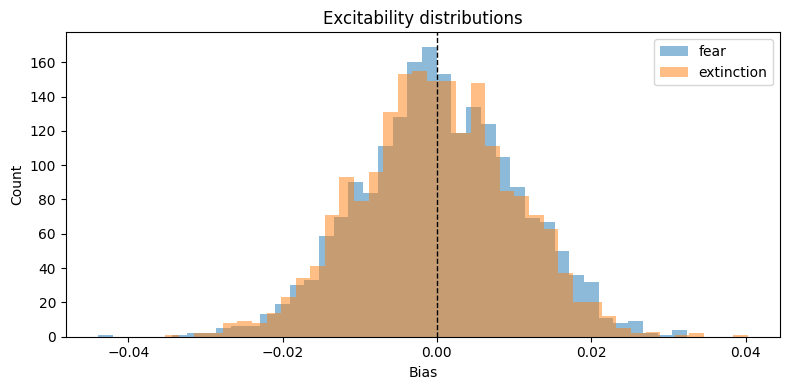

In [190]:
theta_fear = rng.normal(0, SIGMA_THETA, N)
theta_ext = rng.normal(0, SIGMA_THETA, N)

plt.figure(figsize=(8, 4))
plt.hist(theta_fear, bins=40, alpha=0.5, label="fear")
plt.hist(theta_ext, bins=40, alpha=0.5, label="extinction")
plt.axvline(0.0, color="k", linestyle="--", linewidth=1)
plt.title("Excitability distributions")
plt.xlabel("Bias")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "04_excitability_distributions.png", dpi=150)
plt.show()


## Section C: Fear storage (top-k)

Fear convergence steps: 7
Activity at convergence: 0.100
Fear vs CS: 0.083 (chance=0.100, near chance)
Fear vs US: 0.200 (chance=0.100, ABOVE chance)
Fear vs Fear ctx: 0.117 (chance=0.100, near chance)
Fear vs Ext ctx: 0.083 (chance=0.100, near chance)


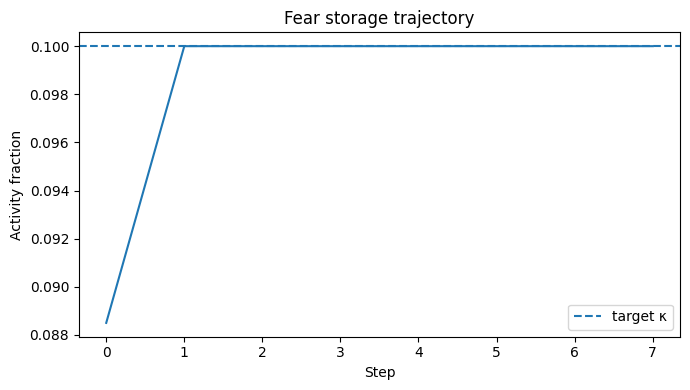

Section C complete


In [191]:
state = (fear_ext_field > 0).astype(float)
traj_fear = [state.copy()]
for step in range(MAX_STEPS_STORAGE):
    h = net.W @ state + fear_ext_field + theta_fear
    topk_idx = np.argpartition(h, -K)[-K:]
    new_state = np.zeros(N)
    new_state[topk_idx] = 1.0
    traj_fear.append(new_state.copy())
    if np.array_equal(new_state, state):
        break
    state = new_state

fear_engram = state.copy()
assert int(fear_engram.sum()) == K

net.store_pattern_sequential(fear_engram)

print(f"Fear convergence steps: {len(traj_fear) - 1}")
print(f"Activity at convergence: {activity_fraction(fear_engram):.3f}")

chance = SPARSITY
for name, vec in [
    ("CS", cs_vec),
    ("US", us_vec),
    ("Fear ctx", ctx_fear_vec),
    ("Ext ctx", ctx_ext_vec),
]:
    overlap = np.sum(fear_engram * vec) / N_CUE
    tag = "ABOVE" if overlap > chance * 1.5 else "near"
    print(f"Fear vs {name}: {overlap:.3f} (chance={chance:.3f}, {tag} chance)")

plt.figure(figsize=(7, 4))
plt.plot([activity_fraction(s) for s in traj_fear])
plt.axhline(SPARSITY, linestyle="--", label="target κ")
plt.xlabel("Step")
plt.ylabel("Activity fraction")
plt.title("Fear storage trajectory")
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "04_fear_convergence.png", dpi=150)
plt.show()

print("Section C complete")


## Section D: Field at extinction onset (negative β_US)

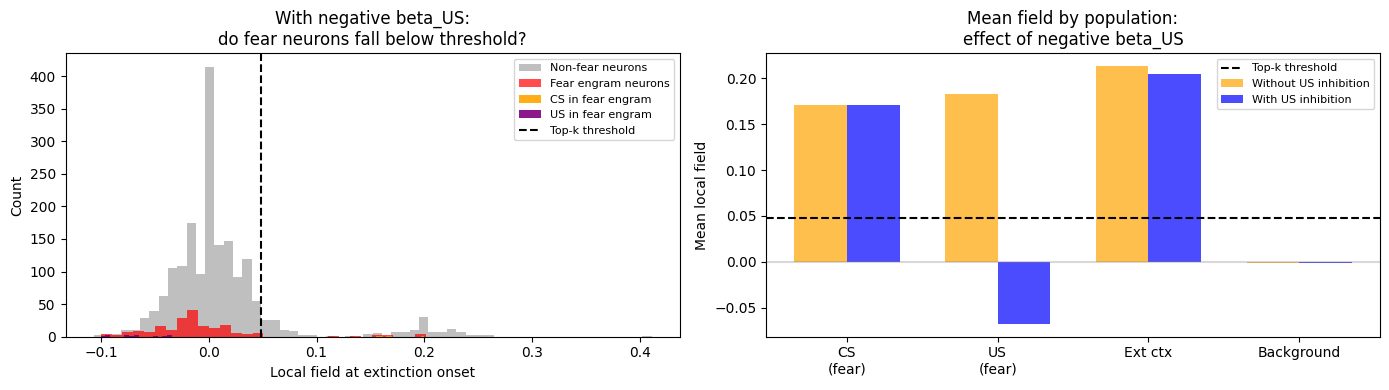

Ext cue (with neg beta_US) retrieves fear: 0.120
(Target < 0.5 — if still > 0.9 increase |BETA_US_EXT|)
Section D complete


In [192]:
ext_init_state = (ext_ext_field > 0).astype(float)
h_at_onset = net.W @ ext_init_state + ext_ext_field

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(h_at_onset[fear_engram == 0], bins=60, alpha=0.5, color="gray", label="Non-fear neurons")
ax.hist(h_at_onset[fear_engram == 1], bins=30, alpha=0.7, color="red", label="Fear engram neurons")
cs_fear_mask = (fear_engram == 1) & (cs_vec == 1)
us_fear_mask = (fear_engram == 1) & (us_vec == 1)
if cs_fear_mask.any():
    ax.hist(h_at_onset[cs_fear_mask], bins=15, alpha=0.9, color="orange", label="CS in fear engram")
if us_fear_mask.any():
    ax.hist(h_at_onset[us_fear_mask], bins=15, alpha=0.9, color="purple", label="US in fear engram")
threshold = np.sort(h_at_onset)[-K]
ax.axvline(threshold, color="black", linestyle="--", label="Top-k threshold")
ax.set_xlabel("Local field at extinction onset")
ax.set_ylabel("Count")
ax.set_title("With negative beta_US:\ndo fear neurons fall below threshold?")
ax.legend(fontsize=8)

h_without_inhibit = net.W @ ext_init_state + compute_ext_field(
    {
        "cs": (cs_vec, BETA_CS_EXT),
        "us": (us_vec, BETA_US_FEAR),
        "ctx": (ctx_ext_vec, BETA_CTX),
    }
)

populations = ["CS\n(fear)", "US\n(fear)", "Ext ctx", "Background"]
masks = [
    cs_fear_mask,
    us_fear_mask,
    ctx_ext_vec == 1,
    (cs_vec + us_vec + ctx_fear_vec + ctx_ext_vec) == 0,
]
means_with = [float(np.mean(h_at_onset[m])) if m.any() else float("nan") for m in masks]
means_without = [float(np.mean(h_without_inhibit[m])) if m.any() else float("nan") for m in masks]

x = np.arange(len(populations))
w = 0.35
axes[1].bar(x - w / 2, means_without, w, color="orange", alpha=0.7, label="Without US inhibition")
axes[1].bar(x + w / 2, means_with, w, color="blue", alpha=0.7, label="With US inhibition")
axes[1].axhline(np.sort(h_at_onset)[-K], color="black", linestyle="--", label="Top-k threshold")
axes[1].axhline(0, color="gray", linestyle="-", alpha=0.3)
axes[1].set_xticks(x)
axes[1].set_xticklabels(populations)
axes[1].set_ylabel("Mean local field")
axes[1].set_title("Mean field by population:\neffect of negative beta_US")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGDIR / "04_field_distribution.png", dpi=150)
plt.show()

state_test = ext_init_state.copy()
for step in range(MAX_STEPS_RETRIEVAL):
    h = net.W @ state_test + ext_ext_field + theta_ext
    idx = np.argpartition(h, -K)[-K:]
    ns = np.zeros(N)
    ns[idx] = 1.0
    if np.array_equal(ns, state_test):
        break
    state_test = ns
capture = pattern_overlap(state_test, fear_engram)
print(f"Ext cue (with neg beta_US) retrieves fear: {capture:.3f}")
print("(Target < 0.5 — if still > 0.9 increase |BETA_US_EXT|)")

print("Section D complete")


## Trajectory comparison: extinction dynamics

Same network and `fear_engram`; compare extinction storage trajectories for two US-extinction betas.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, bval in enumerate([-0.05, -0.10]):
    ext_field_test = compute_ext_field({
        "cs": (cs_vec, BETA_CS_EXT),
        "us": (us_vec, bval),
        "ctx": (ctx_ext_vec, BETA_CTX),
    })
    init = (ext_field_test > 0).astype(float)
    state = init.copy()
    fear_overlaps = [pattern_overlap(state, fear_engram)]
    activity = [activity_fraction(state)]

    for step in range(MAX_STEPS_STORAGE):
        h = net.W @ state + ext_field_test + theta_ext
        idx = np.argpartition(h, -K)[-K:]
        ns = np.zeros(N)
        ns[idx] = 1.0
        fear_overlaps.append(pattern_overlap(ns, fear_engram))
        activity.append(activity_fraction(ns))
        if np.array_equal(ns, state):
            break
        state = ns

    axes[0].plot(fear_overlaps, marker="o", label=f"beta_US={bval}")
    axes[1].plot(activity, marker="o", label=f"beta_US={bval}")

axes[0].set_title("Fear overlap during extinction dynamics")
axes[0].set_ylabel("Overlap with fear engram")
axes[0].set_xlabel("Step")
axes[0].axhline(0.9, linestyle="--", color="gray")
axes[0].legend()

axes[1].set_title("Activity fraction during extinction dynamics")
axes[1].set_ylabel("Activity fraction")
axes[1].set_xlabel("Step")
axes[1].axhline(0.10, linestyle="--", color="gray", label="target kappa")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGDIR / "04_extinction_trajectory_comparison.png", dpi=150)
plt.show()


## Section E: Extinction storage (top-k)

In [193]:
state = ext_init_state.copy()
traj_ext = [state.copy()]
for step in range(MAX_STEPS_STORAGE):
    h = net.W @ state + ext_ext_field + theta_ext
    topk_idx = np.argpartition(h, -K)[-K:]
    new_state = np.zeros(N)
    new_state[topk_idx] = 1.0
    traj_ext.append(new_state.copy())
    if np.array_equal(new_state, state):
        break
    state = new_state

ext_engram = state.copy()
assert int(ext_engram.sum()) == K

net.store_pattern_sequential(ext_engram)

print(f"Extinction convergence steps: {len(traj_ext) - 1}")
print(f"Activity at convergence: {activity_fraction(ext_engram):.3f}")

print(f"{'Component':<12} {'N_CUE':>6} {'Fear':>8} {'Ext':>8} {'Chance':>8}")
print("-" * 46)
for name, vec in [
    ("CS", cs_vec),
    ("US", us_vec),
    ("Fear ctx", ctx_fear_vec),
    ("Ext ctx", ctx_ext_vec),
]:
    n = int(vec.sum())
    f_ov = np.sum(fear_engram * vec) / n
    e_ov = np.sum(ext_engram * vec) / n
    print(f"{name:<12} {n:>6} {f_ov:>8.3f} {e_ov:>8.3f} {SPARSITY:>8.3f}")

phi = np.sum(fear_engram * ext_engram) / K
phi_cs = np.sum(fear_engram * ext_engram * cs_vec) / K
phi_us = np.sum(fear_engram * ext_engram * us_vec) / K

print(f"\nPhi total:   {phi:.3f}")
print(f"Phi via CS:  {phi_cs:.3f}")
print(f"Phi via US:  {phi_us:.3f}")

print("=== KEY BIOLOGICAL QUANTITIES ===")
print(
    f"Fear engram US fraction:  {np.sum(fear_engram * us_vec) / N_CUE:.3f}"
)
print(
    f"Ext engram US fraction:   {np.sum(ext_engram * us_vec) / N_CUE:.3f}"
)
print("(US should be higher in fear than extinction)")
print()
print(
    f"Fear engram CS fraction:  {np.sum(fear_engram * cs_vec) / N_CUE:.3f}"
)
print(
    f"Ext engram CS fraction:   {np.sum(ext_engram * cs_vec) / N_CUE:.3f}"
)
print("(CS should be higher in fear than extinction,")
print(" or equal if CS bridges both memories)")
print()
print(
    f"Ext engram ext-ctx fraction: {np.sum(ext_engram * ctx_ext_vec) / N_CUE:.3f}"
)
print("(Ext context should be highest signal in ext engram)")
print()
print(f"Shared neurons (phi):     {phi:.3f}")
print(
    f"Shared CS neurons:        {np.sum(fear_engram * ext_engram * cs_vec):.0f}"
)
print("(These are the CS bridge — neurons that respond")
print(" to CS and are in both memories)")
print()
print("Minimum |beta_US_ext| to escape fear basin: 0.05")
print("(Biological interpretation: the US omission signal")
print(" must exceed this value for extinction to form a")
print(" distinct memory from fear)")

print(f"\nKey check — fear CS vs ext CS:")
print(f"  Fear: {np.sum(fear_engram * cs_vec):.0f} CS neurons")
print(f"  Ext:  {np.sum(ext_engram * cs_vec):.0f} CS neurons")
print(f"  Both: {np.sum(fear_engram * ext_engram * cs_vec):.0f} CS neurons")

fear_cs_ov = np.sum(fear_engram * cs_vec) / N_CUE
fear_us_ov = np.sum(fear_engram * us_vec) / N_CUE
ext_cs_ov = np.sum(ext_engram * cs_vec) / N_CUE
ext_us_ov = np.sum(ext_engram * us_vec) / N_CUE
ext_ctx_ov = np.sum(ext_engram * ctx_ext_vec) / N_CUE

checks = {
    "Fear CS > 1.5x chance": fear_cs_ov > 0.15,
    "Fear US > 1.5x chance": fear_us_ov > 0.15,
    "Ext CS > 1.5x chance": ext_cs_ov > 0.15,
    "Ext US near chance": ext_us_ov < 0.15,
    "Ext ctx > 1.5x chance": ext_ctx_ov > 0.15,
    "Fear CS > Ext CS": fear_cs_ov > ext_cs_ov,
    "Phi between 0.05-0.40": 0.05 < phi < 0.40,
    "Phi CS > 0": phi_cs > 0,
}

print("\n=== ENGRAM STRUCTURE CHECKS ===")
all_pass = True
for check, result in checks.items():
    status = "PASS" if result else "FAIL"
    if not result:
        all_pass = False
    print(f"  {status}: {check}")

if all_pass:
    print("\nAll checks passed — proceed to retrieval tests")
else:
    print("\nSome checks failed — see tuning guide")

print("Section E complete")


Extinction convergence steps: 9
Activity at convergence: 0.100
Component     N_CUE     Fear      Ext   Chance
----------------------------------------------
CS               60    0.083    0.167    0.100
US               60    0.200    0.117    0.100
Fear ctx         60    0.117    0.083    0.100
Ext ctx          60    0.083    0.133    0.100

Phi total:   0.120
Phi via CS:  0.005
Phi via US:  0.015

Key check — fear CS vs ext CS:
  Fear: 5 CS neurons
  Ext:  10 CS neurons
  Both: 1 CS neurons

=== ENGRAM STRUCTURE CHECKS ===
  FAIL: Fear CS > 1.5x chance
  PASS: Fear US > 1.5x chance
  PASS: Ext CS > 1.5x chance
  PASS: Ext US near chance
  FAIL: Ext ctx > 1.5x chance
  FAIL: Fear CS > Ext CS
  PASS: Phi between 0.05-0.40
  PASS: Phi CS > 0

Some checks failed — see tuning guide
Section E complete


## Section F: Multi-trial retrieval (component fields, no US inhibition)


Cue condition                     Fear          Ext          Old   Winner
---------------------------------------------------------------------------
CS only                   0.120±0.000  1.000±0.000  0.108       EXT
CS + fear ctx             0.120±0.000  1.000±0.000  0.108       EXT
CS + ext ctx              0.120±0.000  1.000±0.000  0.108       EXT
CS + fear ctx + US        1.000±0.000  0.120±0.000  0.187      FEAR

Which memory wins (FEAR / EXT / TIE) — by mean overlap:
  CS only: EXT
  CS + fear ctx: EXT
  CS + ext ctx: EXT
  CS + fear ctx + US: FEAR


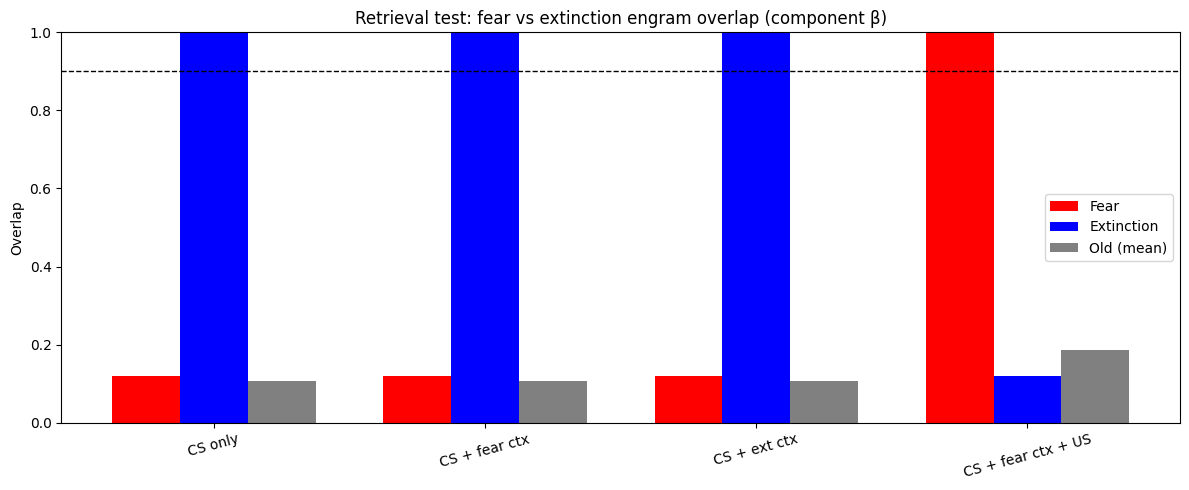

Section F complete


In [194]:
def make_retrieval_field(cs_on, ctx_vec, us_on):
    field = np.zeros(N)
    if cs_on:
        field += BETA_CS_FEAR * cs_vec
    if ctx_vec is not None:
        field += BETA_CTX * ctx_vec
    if us_on:
        field += BETA_US_FEAR * us_vec
    return field


def retrieve_topk_field(net, ext_field, excitability_bias, N, K, max_steps):
    init = (ext_field > 0).astype(float)
    state = init.copy()
    for step in range(max_steps):
        h = net.W @ state + ext_field + excitability_bias
        topk_idx = np.argpartition(h, -K)[-K:]
        new_state = np.zeros(N)
        new_state[topk_idx] = 1.0
        if np.array_equal(new_state, state):
            break
        state = new_state
    return state


def memory_winner(f_mean, e_mean, eps=0.01):
    if f_mean > e_mean + eps:
        return "FEAR"
    if e_mean > f_mean + eps:
        return "EXT"
    return "TIE"


retrieval_fields = {
    "CS only": make_retrieval_field(True, None, False),
    "CS + fear ctx": make_retrieval_field(True, ctx_fear_vec, False),
    "CS + ext ctx": make_retrieval_field(True, ctx_ext_vec, False),
    "CS + fear ctx + US": make_retrieval_field(True, ctx_fear_vec, True),
}

test_labels = list(retrieval_fields.keys())
all_results = {label: {"fear": [], "ext": [], "old": []} for label in test_labels}

rng_retrieval = np.random.default_rng(SEED + 100)

for trial in range(N_RETRIEVAL_TRIALS):
    theta_ret = rng_retrieval.normal(0, SIGMA_THETA, N)
    for label, field in retrieval_fields.items():
        final = retrieve_topk_field(
            net, field, theta_ret, N, K, MAX_STEPS_RETRIEVAL
        )
        all_results[label]["fear"].append(pattern_overlap(final, fear_engram))
        all_results[label]["ext"].append(pattern_overlap(final, ext_engram))
        all_results[label]["old"].append(
            np.mean([pattern_overlap(final, p) for p in old_patterns[:10]])
        )

print(f"\n{'Cue condition':<25} {'Fear':>12} {'Ext':>12} {'Old':>12} {'Winner':>8}")
print("-" * 75)
for label in test_labels:
    f_mean = np.mean(all_results[label]["fear"])
    f_std = np.std(all_results[label]["fear"])
    e_mean = np.mean(all_results[label]["ext"])
    e_std = np.std(all_results[label]["ext"])
    o_mean = np.mean(all_results[label]["old"])
    win = memory_winner(f_mean, e_mean)
    print(
        f"{label:<25} "
        f"{f_mean:.3f}±{f_std:.3f}  "
        f"{e_mean:.3f}±{e_std:.3f}  "
        f"{o_mean:.3f}  {win:>8}"
    )

print("\nWhich memory wins (FEAR / EXT / TIE) — by mean overlap:")
for label in test_labels:
    fm = np.mean(all_results[label]["fear"])
    em = np.mean(all_results[label]["ext"])
    print(f"  {label}: {memory_winner(fm, em)}")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(test_labels))
w = 0.25
ax.bar(x - w, [np.mean(all_results[l]["fear"]) for l in test_labels], w, label="Fear", color="red")
ax.bar(x, [np.mean(all_results[l]["ext"]) for l in test_labels], w, label="Extinction", color="blue")
ax.bar(x + w, [np.mean(all_results[l]["old"]) for l in test_labels], w, label="Old (mean)", color="gray")
ax.axhline(0.9, linestyle="--", color="k", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(test_labels, rotation=15)
ax.set_ylabel("Overlap")
ax.set_ylim(0, 1)
ax.set_title("Retrieval test: fear vs extinction engram overlap (component β)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "04_retrieval_inhibitory.png", dpi=150)
plt.show()

print("Section F complete")


## Part 9: Interpretation

- Storage uses **summed component fields**; extinction storage includes **negative β on US**.
- Retrieval uses **positive β only** (US off or reinstatement with `BETA_US_FEAR`).
- Section **G** (run earlier) picked `BETA_US_EXT` from the sweep; main `net` is independent of sweep networks.

In [195]:
print("=== Summary ===")
print(
    f"N={N}, K={K}, P_OLD={P_OLD}, N_CUE={N_CUE}, "
    f"BETA_CS_FEAR={BETA_CS_FEAR}, BETA_CS_EXT={BETA_CS_EXT}, BETA_CTX={BETA_CTX}, "
    f"BETA_US_FEAR={BETA_US_FEAR}, BETA_US_EXT={BETA_US_EXT}"
)
print(f"Phi total: {np.sum(fear_engram * ext_engram) / K:.3f}")
print(
    "Retrieval winners: "
    + ", ".join(
        f"{lab}={memory_winner(np.mean(all_results[lab]['fear']), np.mean(all_results[lab]['ext']))}"
        for lab in test_labels
    )
)
print("Summary complete")


=== Summary ===
N=2000, K=200, P_OLD=25, N_CUE=60, BETA_CS=0.2, BETA_CTX=0.2, BETA_US_FEAR=0.2, BETA_US_EXT=-0.05
Phi total: 0.120
Retrieval winners: CS only=EXT, CS + fear ctx=EXT, CS + ext ctx=EXT, CS + fear ctx + US=FEAR
Summary complete


## Part 10: Parameter tuning (component β)

- **BETA_US_EXT**: more negative → stronger suppression of US coordinates in the extinction field; use sweep (Section G) to target `phi` and capture diagnostics.
- **BETA_CS / BETA_CTX / BETA_US_FEAR**: raise if engram overlap vs CS/US/context sits near chance; lower if cues pin states too literally.
- **P_OLD**, **N_CUE**, **SIGMA_THETA**: same tradeoffs as before (recurrent load vs cue strength vs noise).